Les accidents sont majoritairement concentrés en semaine, avec un pic marqué aux heures de pointe.

Les départements les plus peuplés concentrent logiquement le plus grand nombre d’accidents.

Les données horaires suggèrent un lien fort avec les déplacements domicile–travail.

La majorité des usagers impliqués sont indemnes ou légèrement blessés

Les accidents mortels restent minoritaires mais concentrés sur certaines plages horaires

Le croisement heure × gravité met en évidence des périodes à risque élevé

# Analyse des accidents de la route — Insights clés (BAAC 2024)

## Objectif
Présenter les principaux enseignements issus de l’analyse des accidents corporels de la circulation
en France à partir des données BAAC 2024, dans une logique d’aide à la décision et de prévention.

In [2]:
import pandas as pd
from pathlib import Path

DATA = Path("../data/processed")
acc = pd.read_parquet(DATA / "accidents-2024.parquet")
usag = pd.read_parquet(DATA / "usagers-2024.parquet")

print(acc.shape, usag.shape)


(70248, 35) (125187, 3)


## Insight 1 — Concentration des accidents aux heures de pointe

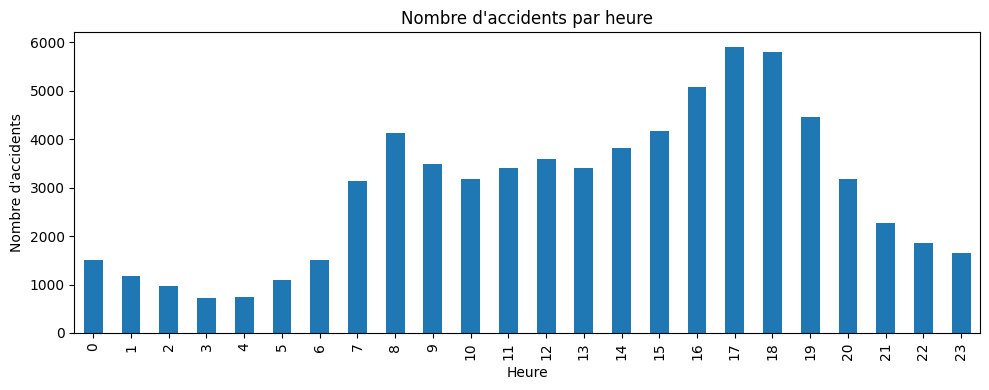

In [3]:
import matplotlib.pyplot as plt

acc["hour"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,4),
    title="Nombre d'accidents par heure"
)

plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")
plt.tight_layout()
plt.show()


Les accidents sont majoritairement concentrés aux heures de pointe,
notamment le matin et en fin de journée. Cette répartition suggère un lien fort avec les déplacements domicile–travail.


## Insight 2 — Répartition hebdomadaire des accidents

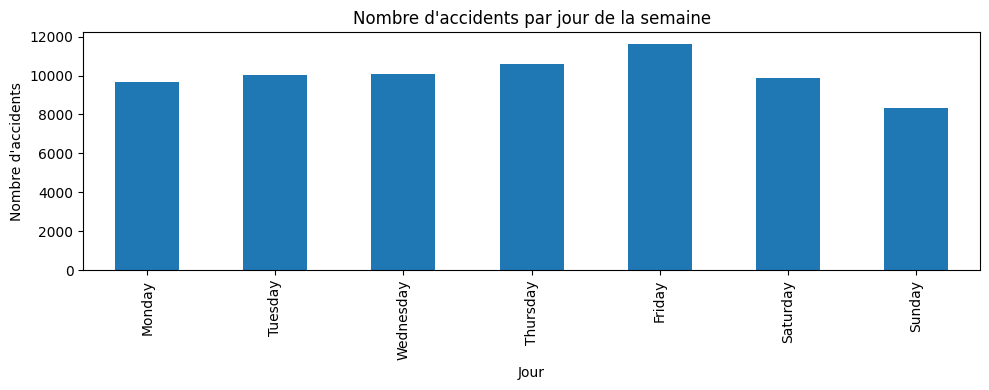

In [4]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

acc["weekday"].value_counts().reindex(order).plot(
    kind="bar",
    figsize=(10,4),
    title="Nombre d'accidents par jour de la semaine"
)

plt.xlabel("Jour")
plt.ylabel("Nombre d'accidents")
plt.tight_layout()
plt.show()


Les accidents sont plus fréquents en semaine, avec une baisse notable le dimanche, confirmant l’impact des déplacements professionnels sur la sinistralité routière.

## Insight 3 — Gravité des accidents impliquant les usagers

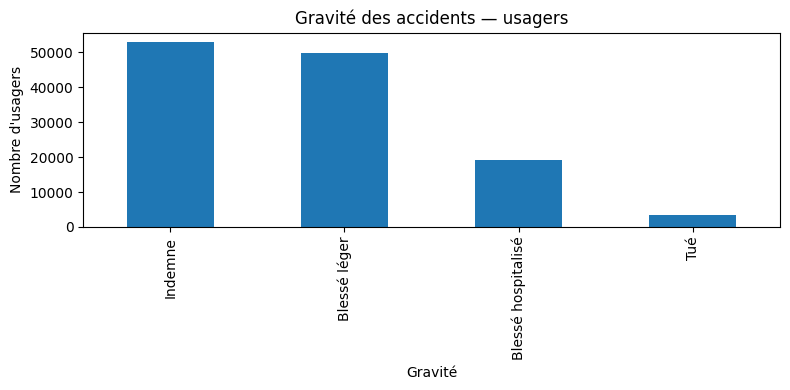

In [5]:
usag["grav_label"].value_counts().reindex(
    ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]
).plot(
    kind="bar",
    figsize=(8,4),
    title="Gravité des accidents — usagers"
)

plt.xlabel("Gravité")
plt.ylabel("Nombre d'usagers")
plt.tight_layout()
plt.show()


La majorité des usagers impliqués dans les accidents sont indemnes ou légèrement blessés.
Les accidents mortels restent minoritaires, mais représentent un enjeu majeur en termes de prévention.

## Insight 4 — Périodes horaires à risque élevé

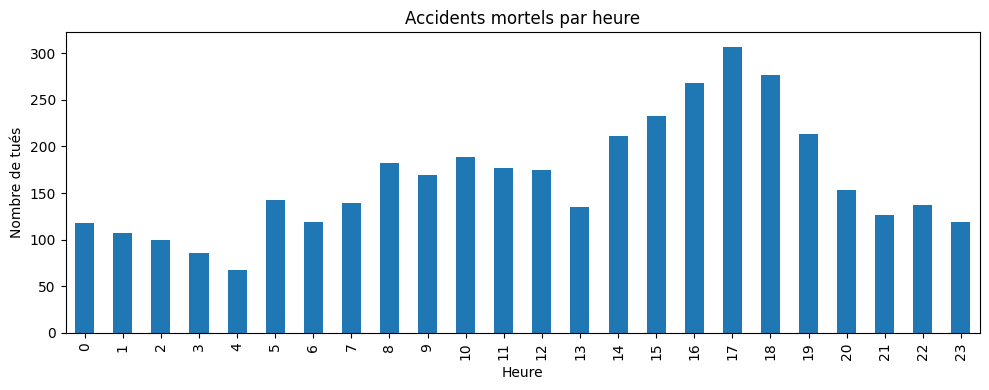

In [6]:
usag_acc = usag.merge(acc[["Num_Acc", "hour"]], on="Num_Acc", how="left")

usag_acc[usag_acc["grav_label"] == "Tué"]["hour"] \
    .value_counts().sort_index().plot(
        kind="bar",
        figsize=(10,4),
        title="Accidents mortels par heure"
    )

plt.xlabel("Heure")
plt.ylabel("Nombre de tués")
plt.tight_layout()
plt.show()


Le croisement entre l’heure de l’accident et la gravité met en évidence des périodes
à risque élevé, durant lesquelles les accidents mortels sont plus fréquents.
Ces créneaux pourraient constituer des cibles prioritaires pour des actions de prévention renforcées.

## Insight 5 — Top Départements

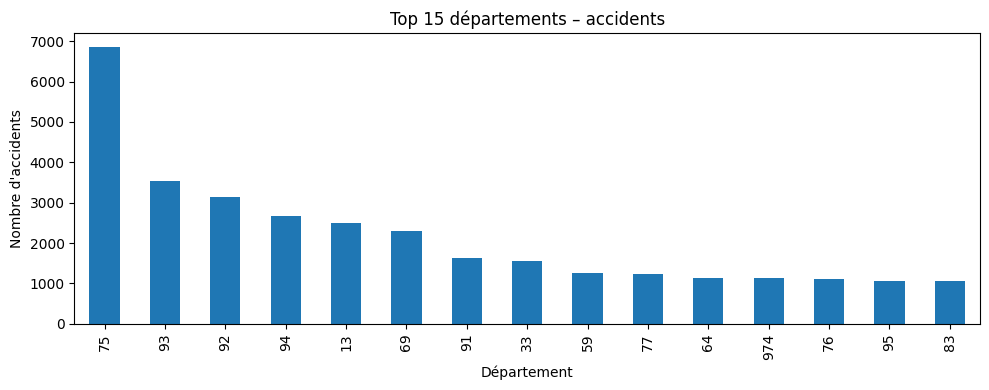

In [7]:
[c for c in acc.columns if c.lower() in ["dep", "departement", "dep_acc"]]
acc["dep"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,4),
    title="Top 15 départements – accidents"
)

plt.xlabel("Département")
plt.ylabel("Nombre d'accidents")
plt.tight_layout()
plt.show()


Les départements les plus peuplés concentrent logiquement le plus grand nombre d’accidents. Cette analyse en volume brut met en évidence des zones prioritaires en termes d’exposition, mais nécessite une normalisation par la population ou le trafic pour évaluer la dangerosité relative.